Consistent hashing: 22.4% keys moved
Naive modulo: 74.4% keys moved

Removal of one node from 3 nodes:
Consistent hashing: 30.5% keys moved
Naive modulo: 65.8% keys moved

Baseline distribution (A,B,C):
  A: 1876 keys
  B: 1525 keys
  C: 1599 keys
After adding D: 22.2% keys moved
  A: 1450 keys
  B: 1203 keys
  C: 1238 keys
  D: 1109 keys
After adding E: 22.0% keys moved
  A: 1091 keys
  B: 973 keys
  E: 1100 keys
  C: 981 keys
  D: 855 keys
After removing B: 19.5% keys moved
  A: 1273 keys
  D: 1186 keys
  E: 1347 keys
  C: 1194 keys


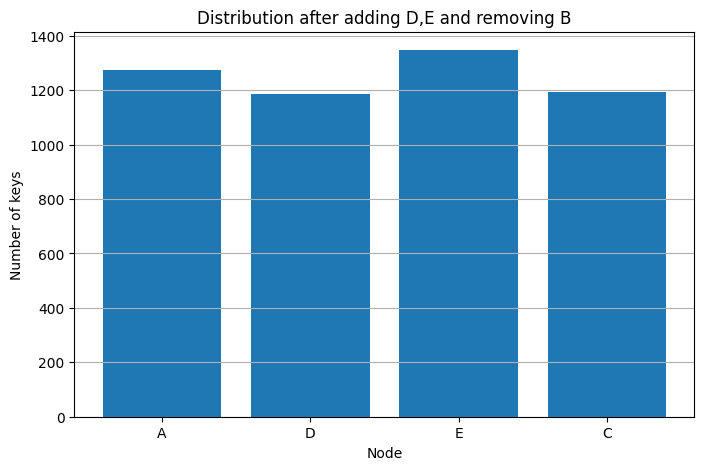

In [2]:
import hashlib
import bisect
import random
import string
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import numpy as np

class ConsistentHash:
    """
    Consistent hash ring with virtual nodes.
    Uses MD5 for hashing.
    """
    def __init__(self, virtual_nodes=100):
        self.virtual_nodes = virtual_nodes  
        self.ring = []                      
        self.hash_to_node = {}              
        self.nodes = set()

    def _hash(self, key):
        """Return integer hash for a key (string or bytes)."""
        if isinstance(key, str):
            key = key.encode()
        return int(hashlib.md5(key).hexdigest(), 16)

    def _add_virtual_nodes(self, node):
        """Add virtual nodes for a given real node."""
        for i in range(self.virtual_nodes):
            virtual_key = f"{node}:vnode:{i}"
            h = self._hash(virtual_key)
            bisect.insort(self.ring, h)
            self.hash_to_node[h] = node

    def add_node(self, node):
        """Add a real node to the ring."""
        if node in self.nodes:
            return
        self.nodes.add(node)
        self._add_virtual_nodes(node)

    def remove_node(self, node):
        """Remove a real node and all its virtual nodes."""
        if node not in self.nodes:
            return

        new_ring = []
        for h in self.ring:
            if self.hash_to_node[h] == node:
                del self.hash_to_node[h]
            else:
                new_ring.append(h)
        self.ring = new_ring
        self.nodes.remove(node)

    def get_node(self, key):
        """Return the node responsible for the given key."""
        if not self.ring:
            return None
        h = self._hash(key)

        idx = bisect.bisect_left(self.ring, h)
        if idx == len(self.ring):
            idx = 0
        responsible_hash = self.ring[idx]
        return self.hash_to_node[responsible_hash]

    def get_distribution(self, keys):
        """Return mapping node -> list of keys assigned."""
        dist = defaultdict(list)
        for key in keys:
            node = self.get_node(key)
            dist[node].append(key)
        return dist

def naive_hash_distribution(keys, num_nodes):
    """Simple modulo distribution (hash(key) % num_nodes)."""
    dist = defaultdict(list)
    for key in keys:
        node = hash(key) % num_nodes
        dist[node].append(key)
    return dist

def generate_keys(n, length=10):
    """Generate n random strings."""
    keys = []
    for _ in range(n):
        key = ''.join(random.choices(string.ascii_lowercase + string.digits, k=length))
        keys.append(key)
    return keys

def compute_rebalance_ratio(old_dist, new_dist):
    """Compute fraction of keys that moved."""

    old_map = {key: node for node, keys in old_dist.items() for key in keys}
    new_map = {key: node for node, keys in new_dist.items() for key in keys}
    moved = sum(1 for key in old_map if old_map[key] != new_map[key])
    return moved / len(old_map)

def benchmark_consistent_hashing():
    """Compare consistent hashing vs naive modulo when adding/removing nodes."""

    num_keys = 10000
    keys = generate_keys(num_keys)
    nodes = ['A', 'B', 'C']

    ch = ConsistentHash(virtual_nodes=200)
    for node in nodes:
        ch.add_node(node)

    naive_nodes = 3

    ch_initial = ch.get_distribution(keys)
    naive_initial = naive_hash_distribution(keys, naive_nodes)

    new_node = 'D'
    ch.add_node(new_node)
    naive_nodes_new = 4
    ch_new = ch.get_distribution(keys)
    naive_new = naive_hash_distribution(keys, naive_nodes_new)

    ch_ratio = compute_rebalance_ratio(ch_initial, ch_new)
    naive_ratio = compute_rebalance_ratio(naive_initial, naive_new)

    print(f"Consistent hashing: {ch_ratio*100:.1f}% keys moved")
    print(f"Naive modulo: {naive_ratio*100:.1f}% keys moved")

    ch.remove_node('B')
    naive_nodes_removed = 2  

    naive_initial_removal = naive_hash_distribution(keys, 3)
    naive_removed = naive_hash_distribution(keys, 2)
    ch_initial_removal = ch.get_distribution(keys)

    ch2 = ConsistentHash(virtual_nodes=200)
    for node in nodes:
        ch2.add_node(node)
    ch_initial_removal = ch2.get_distribution(keys)
    ch2.remove_node('B')
    ch_removed = ch2.get_distribution(keys)

    naive_removed_ratio = compute_rebalance_ratio(naive_initial_removal, naive_removed)
    ch_removed_ratio = compute_rebalance_ratio(ch_initial_removal, ch_removed)

    print(f"\nRemoval of one node from 3 nodes:")
    print(f"Consistent hashing: {ch_removed_ratio*100:.1f}% keys moved")
    print(f"Naive modulo: {naive_removed_ratio*100:.1f}% keys moved")

    return ch, ch_initial, ch_new

def visualize_distribution(dist, title):
    """Plot bar chart of keys per node."""
    nodes = list(dist.keys())
    counts = [len(dist[node]) for node in nodes]
    plt.figure(figsize=(8,5))
    plt.bar(nodes, counts)
    plt.title(title)
    plt.xlabel('Node')
    plt.ylabel('Number of keys')
    plt.grid(axis='y')
    plt.show()

def simulate_rebalancing_with_nodes():
    """Simulate gradual addition of nodes and plot movement."""
    keys = generate_keys(5000)
    nodes = ['A', 'B', 'C']

    ch = ConsistentHash(virtual_nodes=200)
    for node in nodes:
        ch.add_node(node)

    base_dist = ch.get_distribution(keys)
    print("\nBaseline distribution (A,B,C):")
    for node, ks in base_dist.items():
        print(f"  {node}: {len(ks)} keys")

    ch.add_node('D')
    new_dist = ch.get_distribution(keys)
    moved = compute_rebalance_ratio(base_dist, new_dist)
    print(f"After adding D: {moved*100:.1f}% keys moved")

    for node, ks in new_dist.items():
        print(f"  {node}: {len(ks)} keys")

    ch.add_node('E')
    new_dist2 = ch.get_distribution(keys)
    moved2 = compute_rebalance_ratio(new_dist, new_dist2)
    print(f"After adding E: {moved2*100:.1f}% keys moved")
    for node, ks in new_dist2.items():
        print(f"  {node}: {len(ks)} keys")

    ch.remove_node('B')
    new_dist3 = ch.get_distribution(keys)
    moved3 = compute_rebalance_ratio(new_dist2, new_dist3)
    print(f"After removing B: {moved3*100:.1f}% keys moved")
    for node, ks in new_dist3.items():
        print(f"  {node}: {len(ks)} keys")

    visualize_distribution(new_dist3, "Distribution after adding D,E and removing B")

if __name__ == "__main__":
    benchmark_consistent_hashing()
    simulate_rebalancing_with_nodes()